*Aprendizaje Profundo*  
*Clasificador Perros y Gatos con Transfer Learning*  
*Autor:* Ing. Daniel Eduardo González Alvarado  
*Profesor:* Dr. Sebastian Salazar

# Cargar Librerias

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# Cargar DB (Imagenes Entrenamiento)

In [6]:
data_dir = pathlib.Path("./DB/cats_and_dogs_small")

batch_size = 32
img_size = (160, 160)   # alto, ancho
IMG_HEIGHT, IMG_WIDTH = img_size

# Separar en Train & Test

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Clases:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
Clases: ['cats', 'dogs']


# Modelo preentrenado (MobilNetV2)

In [8]:
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

# Congelar el modelo para la primera parte de entrenamiento
base_model.trainable = False

# Modelo con Transfer Learning

In [9]:
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Preprocesamiento de MobileNetV2
x = preprocess_input(inputs)

# Extracción de características
x = base_model(x, training=False)

# Pooling global
x = layers.GlobalAveragePooling2D()(x)

# Capa final binaria (gato vs perro)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compilar Y Entrenar

In [10]:
# Solo capas Nuevas
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

epochs = 5
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step - accuracy: 0.8855 - loss: 0.2740 - val_accuracy: 0.9812 - val_loss: 0.0690
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.9814 - loss: 0.0620 - val_accuracy: 0.9812 - val_loss: 0.0514
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - accuracy: 0.9869 - loss: 0.0456 - val_accuracy: 0.9825 - val_loss: 0.0465
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.9875 - loss: 0.0414 - val_accuracy: 0.9812 - val_loss: 0.0485
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.9865 - loss: 0.0403 - val_accuracy: 0.9837 - val_loss: 0.0381


# Fine Tunning

In [11]:
# Descongelar el modelo base completo
base_model.trainable = True

# Solo afinar capas finales del modelo base
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compilar de nuevo con learning rate más pequeño
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5
total_epochs = epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)


Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 267ms/step - accuracy: 0.8500 - loss: 0.3499 - val_accuracy: 0.9750 - val_loss: 0.0541
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.9637 - loss: 0.0985 - val_accuracy: 0.9762 - val_loss: 0.0536
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.9892 - loss: 0.0600 - val_accuracy: 0.9800 - val_loss: 0.0449
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 276ms/step - accuracy: 0.9955 - loss: 0.0380 - val_accuracy: 0.9812 - val_loss: 0.0416
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 278ms/step - accuracy: 0.9985 - loss: 0.0248 - val_accuracy: 0.9812 - val_loss: 0.0401
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 273ms/step - accuracy: 1.0000 - loss: 0.0186 - val_accuracy: 0.9825 - val_loss: 0.0396


# Guardar Modelo

In [13]:
model.save("./modelos/cats_dogs_mobilenetv2.keras")
print("Modelo guardado")

Modelo guardado


# Cargar Modelo

In [14]:
from tensorflow.keras.models import load_model

model = load_model("./modelos/cats_dogs_mobilenetv2.keras")

# Ver el input_shape para predicciones
print("Input shape:", model.input_shape)


Input shape: (None, 160, 160, 3)


C:\Users\death\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 58 variables whereas the saved optimizer has 114 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Prediccion

In [15]:
def predict_image(img_path, model, img_size=(160, 160)):
    img = load_img(img_path, target_size=img_size)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)  # (1, h, w, 3)

    pred = model.predict(arr)[0][0]

    plt.imshow(load_img(img_path))
    plt.axis("off")
    label = class_names[1] if pred > 0.5 else class_names[0]
    title = f"{label} (score={pred:.3f})"
    plt.title(title)
    plt.show()

    print("Predicción:", title)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


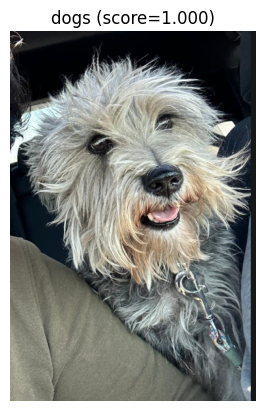

Predicción: dogs (score=1.000)


In [19]:
path = "./img/annie2.png"
predict_image(path, model)